# LLMs as Token-Level MDPs

You already know PPO in the classical setting. The new thing is learning to look at **autoregressive generation itself as an RL trajectory**.

> **Note:** Papers will appear exactly where they become useful, not dumped as a reading list upfront. Some lessons may have no paper if reading one there would add noise.

# Module 3 — Lesson 3.1: LLMs as Token-Level MDPs

You already know PPO in the classical setting. The new thing is learning to look at **autoregressive generation itself as an RL trajectory**.

Your existing work already treats generation as repeated next-token sampling from a decoder LM, so we're building directly on that rather than revisiting Transformer internals.

---

## 1. The Mapping

**Classical RL:**

$$s_t \rightarrow a_t \rightarrow r_t \rightarrow s_{t+1}$$

**For an LLM:**

$$s_t = (x, y_{<t})$$

$$a_t = y_t$$

Where:
- $x$ = prompt
- $y_{<t}$ = tokens already generated
- $y_t$ = next generated token

**Step-by-step Execution:**

```text
Prompt:
"2 + 2 ="

State s0:
"2 + 2 ="

Action a0:
" 4"

State s1:
"2 + 2 = 4"

Action a1:
"<EOS>"
```

The **policy** is simply:

$$\pi_\theta(a_t | s_t) = P_\theta(y_t | x, y_{<t})$$

That's just the probability distribution from your LM head.

Nothing magical happened — your language model was already a stochastic policy.

---

## 2. What is an Episode?

Suppose:

```text
Prompt:
"What is 15 * 3?"

Generation:
"The answer is 45."
```

Tokenized conceptually:

```text
Prompt tokens:
[What] [is] [15] [*] [3] [?]

Generated tokens:
[The] [answer] [is] [45] [.] [EOS]
```

The RL trajectory is:

```text
s0 → "The"
s1 → "answer"
s2 → "is"
s3 → "45"
s4 → "."
s5 → EOS
```

Therefore, one response is normally one episode:

$$\tau = (s_0, a_0, s_1, a_1, \dots, s_T, a_T)$$

For **single-turn RLHF**, that's enough. Module 4 will break this assumption when tools and multiple conversation turns enter the environment.

---

## 3. The Critical Distinction: Prompt Tokens are NOT Actions

Consider:

```text
[USER]      What is 15 * 3?
[ASSISTANT] The answer is 45.
```

The model did **not** choose:

```text
What
is
15
*
3
?
```

Those came from the environment/user.

It **only** chose:

```text
The
answer
is
45
.
EOS
```

Therefore PPO must **only** optimize the generated region. We need an **action mask**:

```text
tokens:  [What] [is] [15] [*] [3] [?] [The] [answer] [is] [45] [.] [EOS]
mask:       0     0    0   0   0   0    1      1      1    1    1    1
```

This tiny-looking idea is fundamental. If you accidentally calculate policy loss on prompt tokens, you're optimizing actions the policy never took.

---

## 4. Three Masks You Should Stop Confusing

We'll encounter several masks:

### A. Attention Mask

Controls which real tokens exist versus padding.

```text
1 1 1 1 1 1 1 1 0 0
```

Usually referenced as `attention_mask`.

---

### B. Causal Mask

Inside attention: token $t$ cannot see future tokens.

```text
token t cannot see future tokens
```

You've already implemented this concept in causal self-attention. Usually Qwen handles this internally.

---

### C. Response / Action Mask

Our RL-specific mask:

```text
prompt   = 0
response = 1
padding  = 0
```

**Example:**

```text
Prompt      Response       Padding
0 0 0 0     1 1 1 1       0 0 0
```

This determines which tokens participate in:
- policy loss
- value loss
- KL divergence
- advantages
- returns
- entropy statistics

depending on the algorithm. This mask becomes **extremely important** later.

---

## 5. Where Does Reward Live?

This is where LLM RL starts becoming interesting. Suppose Qwen generates: `"The answer is 45."` and our verifier gives $R = 1$.

The simplest representation is **terminal reward**:

```text
The       0
answer    0
is        0
45        0
.         0
EOS       +1
```

So:

$$r_t = 0 \qquad \text{for } t < T$$

and:

$$r_T = R(x, y)$$

This creates a **credit-assignment problem**. Every token helped create the successful answer, yet the reward appears only at the end.

That's one reason we later need:
- critic
- returns
- GAE (Generalized Advantage Estimation)
- advantages

But **do not jump there yet**. First we need correct trajectories.

---

## 6. RLHF Introduces Another Token Reward

Later we'll add KL regularization. Then the reward may look approximately like:

$$r_t^{\text{KL}} = -\beta \left( \log\pi_\theta(a_t|s_t) - \log\pi_{\text{ref}}(a_t|s_t) \right)$$

for every generated token. And at the final token:

$$r_T = r_T^{\text{KL}} + R_{\text{task}}$$

So eventually:

```text
token 1       KL penalty
token 2       KL penalty
token 3       KL penalty
...
final token   KL penalty + RM/verifier reward
```

Don't implement this today. I'm showing it so the trajectory format we build **won't need to be redesigned later**.

---

## 7. What Exactly Do We Store?

This is today's main engineering goal. For every rollout:

```python
Trajectory(
    prompt_ids,
    response_ids,
    input_ids,
    attention_mask,
    action_mask,
)
```

Soon this becomes:

```python
Trajectory(
    prompt_ids,
    response_ids,
    input_ids,
    attention_mask,
    action_mask,

    old_logprobs,
    ref_logprobs,

    rewards,
    values,
    advantages,
    returns,

    metadata,
)
```

But **Lesson 3.1 only owns the first five**.

---

## 8. Shape Discipline

Suppose:

```text
batch_size = B
total_sequence_length = T
```

Then:

```text
input_ids       [B, T]
attention_mask  [B, T]
action_mask     [B, T]
```

Later:

```text
old_logprobs    [B, T-1]
ref_logprobs    [B, T-1]
values          [B, T-1]
rewards         [B, T-1]
advantages      [B, T-1]
returns         [B, T-1]
```

Why often $T-1$? Because:

```text
token at position t  ──predicts──>  token at position t+1
```

For logits:
```python
logits[:, :-1]
```

correspond to targets:
```python
input_ids[:, 1:]
```

This off-by-one alignment bug is one of the easiest ways to silently screw up RLHF training. We'll explicitly test it next lesson.

---

## 9. Qwen Rollout Pipeline

For our Qwen 1.5B setup:

```text
Prompt
  │
  ▼
Tokenizer
  │
  ▼
prompt_ids
  │
  ▼
Qwen.generate()
  │
  ▼
prompt + response IDs
  │
  ├── identify generated span
  │
  ├── construct action mask
  │
  └── decode response
  │
  ▼
Trajectory
```

### Notice:

#### `generate()` is NOT the Trainer

It's our **environment interaction / rollout engine**. That's an important architectural separation.

Later:

```text
ROLL OUT
Qwen → trajectories

OPTIMIZE
trajectories → PPO/GRPO → parameter update
```

Don't mix those two pieces.

---

### Shift in Paradigm

**Before (LLM Generation):**

```text
prompt  ──>  model.generate()  ──>  text
```

**Now (RL Rollout):**

```text
initial state
     │
     ▼
   policy
     │
     ▼
 action/token
     │
     ▼
new state/prefix
     │
     ▼
   policy
     │
     ▼
 action/token
     │
     ▼
    ...
     │
     ▼
terminal response
```

And simultaneously:

$$\text{generated text} = \text{RL trajectory}$$

That single reinterpretation unlocks everything we're about to do.

## Qwen Rollout Collector

In [1]:
import time
import random
from dataclasses import dataclass
from typing import Optional, List

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print(
        "GPU VRAM       :",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )

c:\WHATEVERELSE\GeekStuff\conda\envs\pygpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.7.1+cu118
CUDA available  : True
Device          : cuda
GPU             : NVIDIA GeForce RTX 3050 Laptop GPU
GPU VRAM       : 4.0 GB


> **Important Design Principle:**
> 
> Rollout generation = inference.
> 
> So for now:
> - No optimizer
> - No gradients
> - No value head
> - No PPO
> - No GRPO
> 
> We are building the trajectory-producing side first.

In [2]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

if torch.cuda.is_available():
    if torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
else:
    model_dtype = torch.float32

print("Loading:", MODEL_NAME)
print("dtype  :", model_dtype)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=model_dtype,
)

model = model.to(device)
model.eval()

print("\nModel loaded.")
print("Model device:", next(model.parameters()).device)

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters    : {num_params / 1e9:.3f} B")
print(f"Trainable parameters: {trainable_params / 1e9:.3f} B")

Loading: Qwen/Qwen2.5-1.5B-Instruct
dtype  : torch.bfloat16


`torch_dtype` is deprecated! Use `dtype` instead!



Model loaded.
Model device: cuda:0
Total parameters    : 1.544 B
Trainable parameters: 1.544 B


In [3]:
messages = [
    {
        "role": "user",
        "content": "What is 15 multiplied by 3?"
    }
]

formatted_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print("=== RAW USER MESSAGE ===")
print(messages[0]["content"])

print("\n=== ACTUAL TEXT GIVEN TO QWEN ===")
print(repr(formatted_prompt))

print("\n=== HUMAN-READABLE VERSION ===")
print(formatted_prompt)

=== RAW USER MESSAGE ===
What is 15 multiplied by 3?

=== ACTUAL TEXT GIVEN TO QWEN ===
'<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat is 15 multiplied by 3?<|im_end|>\n<|im_start|>assistant\n'

=== HUMAN-READABLE VERSION ===
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is 15 multiplied by 3?<|im_end|>
<|im_start|>assistant



In [4]:
prompt_encoding = tokenizer(
    formatted_prompt,
    return_tensors="pt",
    add_special_tokens=False,
)

prompt_ids = prompt_encoding["input_ids"].to(device)
prompt_attention_mask = prompt_encoding["attention_mask"].to(device)

print("input_ids shape      :", prompt_ids.shape)
print("attention_mask shape :", prompt_attention_mask.shape)

print("\nPrompt token count:", prompt_ids.shape[1])

input_ids shape      : torch.Size([1, 39])
attention_mask shape : torch.Size([1, 39])

Prompt token count: 39


In [5]:
prompt_tokens = []

for position, token_id in enumerate(prompt_ids[0].tolist()):
    token_text = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    prompt_tokens.append({
        "position": position,
        "token_id": token_id,
        "token": repr(token_text),
        "source": "ENVIRONMENT",
        "action": False,
    })

prompt_df = pd.DataFrame(prompt_tokens)

prompt_df

,position,token_id,token,source,action
0,0,151644,'<|im_start|>',ENVIRONMENT,False
1,1,8948,'system',ENVIRONMENT,False
2,2,198,'\n',ENVIRONMENT,False
3,3,2610,'You',ENVIRONMENT,False
4,4,525,' are',ENVIRONMENT,False
5,5,1207,' Q',ENVIRONMENT,False
6,6,16948,'wen',ENVIRONMENT,False
7,7,11,"','",ENVIRONMENT,False
8,8,3465,' created',ENVIRONMENT,False
9,9,553,' by',ENVIRONMENT,False


In [6]:
MAX_NEW_TOKENS = 64

with torch.inference_mode():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    generated_ids = model.generate(
        input_ids=prompt_ids,
        attention_mask=prompt_attention_mask,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=True,
        temperature=0.8,
        top_p=0.95,
        pad_token_id=tokenizer.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    generation_time = time.perf_counter() - start_time

print("Generated tensor shape:", generated_ids.shape)
print(f"Generation time: {generation_time:.3f} seconds")

Generated tensor shape: torch.Size([1, 54])
Generation time: 5.326 seconds


In [7]:
prompt_length = prompt_ids.shape[1]

response_ids = generated_ids[:, prompt_length:]

response_length = response_ids.shape[1]

response_text = tokenizer.decode(
    response_ids[0],
    skip_special_tokens=True
)

print("Prompt length   :", prompt_length)
print("Response length :", response_length)

print("\n=== RESPONSE ===")
print(response_text)

Prompt length   : 39
Response length : 15

=== RESPONSE ===
The product of 15 and 3 is 45.


### Conceptually:

```text
prompt                  response
  ↓                        ↓
0 0 0 0 0 0 0 0 0      1 1 1 1 1 1 ...
```

In [8]:
action_mask = torch.zeros_like(generated_ids, dtype=torch.bool)

action_mask[:, prompt_length:] = True

print("generated_ids shape :", generated_ids.shape)
print("action_mask shape   :", action_mask.shape)

print("\nAction tokens:", action_mask.sum().item())
print("Expected     :", response_length)

assert action_mask.sum().item() == response_length

print("\nMask sanity check passed.")

generated_ids shape : torch.Size([1, 54])
action_mask shape   : torch.Size([1, 54])

Action tokens: 15
Expected     : 15

Mask sanity check passed.


In [9]:
trajectory_rows = []

for position, (token_id, is_action) in enumerate(
    zip(
        generated_ids[0].tolist(),
        action_mask[0].tolist()
    )
):
    token_text = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    trajectory_rows.append({
        "position": position,
        "token_id": token_id,
        "token": repr(token_text),
        "source": "POLICY" if is_action else "ENVIRONMENT",
        "action_mask": int(is_action),
    })

trajectory_df = pd.DataFrame(trajectory_rows)

trajectory_df

,position,token_id,token,source,action_mask
0,0,151644,'<|im_start|>',ENVIRONMENT,0
1,1,8948,'system',ENVIRONMENT,0
2,2,198,'\n',ENVIRONMENT,0
3,3,2610,'You',ENVIRONMENT,0
4,4,525,' are',ENVIRONMENT,0
5,5,1207,' Q',ENVIRONMENT,0
6,6,16948,'wen',ENVIRONMENT,0
7,7,11,"','",ENVIRONMENT,0
8,8,3465,' created',ENVIRONMENT,0
9,9,553,' by',ENVIRONMENT,0


> When we later add `logprobs`, `advantages`, `rewards`, and `KL`, we'll extend essentially this same inspection table.

In [10]:
print("=" * 90)
print(f"{'POS':<6} {'MASK':<6} {'SOURCE':<14} TOKEN")
print("=" * 90)

for row in trajectory_rows:
    print(
        f"{row['position']:<6} "
        f"{row['action_mask']:<6} "
        f"{row['source']:<14} "
        f"{row['token']}"
    )

POS    MASK   SOURCE         TOKEN
0      0      ENVIRONMENT    '<|im_start|>'
1      0      ENVIRONMENT    'system'
2      0      ENVIRONMENT    '\n'
3      0      ENVIRONMENT    'You'
4      0      ENVIRONMENT    ' are'
5      0      ENVIRONMENT    ' Q'
6      0      ENVIRONMENT    'wen'
7      0      ENVIRONMENT    ','
8      0      ENVIRONMENT    ' created'
9      0      ENVIRONMENT    ' by'
10     0      ENVIRONMENT    ' Alibaba'
11     0      ENVIRONMENT    ' Cloud'
12     0      ENVIRONMENT    '.'
13     0      ENVIRONMENT    ' You'
14     0      ENVIRONMENT    ' are'
15     0      ENVIRONMENT    ' a'
16     0      ENVIRONMENT    ' helpful'
17     0      ENVIRONMENT    ' assistant'
18     0      ENVIRONMENT    '.'
19     0      ENVIRONMENT    '<|im_end|>'
20     0      ENVIRONMENT    '\n'
21     0      ENVIRONMENT    '<|im_start|>'
22     0      ENVIRONMENT    'user'
23     0      ENVIRONMENT    '\n'
24     0      ENVIRONMENT    'What'
25     0      ENVIRONMENT    ' is'
26     0

### Attention Mask vs. Action Mask

Right now there is no padding, so our full attention mask is simply all ones.

*Cell: Build full attention mask*

In [11]:
full_attention_mask = torch.ones_like(
    generated_ids,
    dtype=torch.long
)

comparison_df = pd.DataFrame({
    "position": list(range(generated_ids.shape[1])),
    "token": [
        repr(
            tokenizer.decode(
                [token_id],
                skip_special_tokens=False
            )
        )
        for token_id in generated_ids[0].tolist()
    ],
    "attention_mask": full_attention_mask[0].cpu().tolist(),
    "action_mask": action_mask[0].int().cpu().tolist(),
})

comparison_df

,position,token,attention_mask,action_mask
0,0,'<|im_start|>',1,0
1,1,'system',1,0
2,2,'\n',1,0
3,3,'You',1,0
4,4,' are',1,0
5,5,' Q',1,0
6,6,'wen',1,0
7,7,"','",1,0
8,8,' created',1,0
9,9,' by',1,0


### Why Are They Different?

Because the prompt is:
- Visible to the model
- Part of the state

but:
- **Not an action**
- **Not something PPO/GRPO should optimize as an action**

So:

$$\text{attention mask} \neq \text{action mask}$$

In [12]:
print("EOS token     :", repr(tokenizer.eos_token))
print("EOS token ID  :", tokenizer.eos_token_id)

print("PAD token     :", repr(tokenizer.pad_token))
print("PAD token ID  :", tokenizer.pad_token_id)

print("\nSpecial tokens map:")
print(tokenizer.special_tokens_map)

EOS token     : '<|im_end|>'
EOS token ID  : 151645
PAD token     : '<|endoftext|>'
PAD token ID  : 151643

Special tokens map:
{'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>', 'additional_special_tokens': ['<|im_start|>', '<|im_end|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']}


In [13]:
eos_token_id = tokenizer.eos_token_id

response_token_list = response_ids[0].tolist()

eos_positions = [
    i
    for i, token_id in enumerate(response_token_list)
    if token_id == eos_token_id
]

eos_reached = len(eos_positions) > 0

if eos_reached:
    first_eos_position = eos_positions[0]
else:
    first_eos_position = None

print("EOS reached        :", eos_reached)
print("First EOS position :", first_eos_position)
print("Response tokens    :", response_length)

EOS reached        : True
First EOS position : 14
Response tokens    : 15


In [14]:
hit_max_new_tokens = (
    response_length >= MAX_NEW_TOKENS
    and not eos_reached
)

print("EOS reached        :", eos_reached)
print("Hit max_new_tokens :", hit_max_new_tokens)

if eos_reached:
    print("Termination reason : EOS")
elif hit_max_new_tokens:
    print("Termination reason : MAX_NEW_TOKENS / TRUNCATED")
else:
    print("Termination reason : OTHER")

EOS reached        : True
Hit max_new_tokens : False
Termination reason : EOS


### Define Our Actual Trajectory Object

Now that every field has a clear meaning, let's create the trajectory object.

In [15]:
@dataclass
class LLMTrajectory:
    # Text
    prompt_text: str
    response_text: str

    # Core tensors
    input_ids: torch.Tensor
    attention_mask: torch.Tensor
    action_mask: torch.Tensor

    # Sequence metadata
    prompt_length: int
    response_length: int

    # Termination metadata
    eos_reached: bool
    truncated: bool

    # Performance metadata
    generation_time: float
    tokens_per_second: float

    def summary(self):
        return {
            "prompt_length": self.prompt_length,
            "response_length": self.response_length,
            "eos_reached": self.eos_reached,
            "truncated": self.truncated,
            "generation_time_sec": self.generation_time,
            "tokens_per_second": self.tokens_per_second,
        }

> **Notice what is deliberately absent:**
> 
> - `old_logprobs`
> - `reference_logprobs`
> - `reward`
> - `value`
> - `advantage`
> - `return`
> 
> Those don't belong to this part of the codebase yet.

In [16]:
@torch.inference_mode()
def collect_rollout(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 64,
    temperature: float = 0.8,
    top_p: float = 0.95,
):
    """
    Generate one single-turn LLM RL trajectory.

    Returns:
        LLMTrajectory
    """

    # ---------------------------------------------------------
    # 1. Convert user prompt into Qwen chat format
    # ---------------------------------------------------------
    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    # ---------------------------------------------------------
    # 2. Tokenize the environment/context
    # ---------------------------------------------------------
    encoded = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        add_special_tokens=False,
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    prompt_length = input_ids.shape[1]

    # ---------------------------------------------------------
    # 3. Generate policy actions
    # ---------------------------------------------------------
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    generated_ids = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tokenizer.eos_token_id,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    generation_time = time.perf_counter() - start_time

    # ---------------------------------------------------------
    # 4. Extract only policy-generated actions
    # ---------------------------------------------------------
    response_ids = generated_ids[:, prompt_length:]

    response_length = response_ids.shape[1]

    # ---------------------------------------------------------
    # 5. Action mask
    # ---------------------------------------------------------
    action_mask = torch.zeros_like(
        generated_ids,
        dtype=torch.bool,
    )

    action_mask[:, prompt_length:] = True

    # ---------------------------------------------------------
    # 6. Full attention mask
    #
    # Single unpadded trajectory => every token exists.
    # Batched variable-length trajectories come later.
    # ---------------------------------------------------------
    full_attention_mask = torch.ones_like(
        generated_ids,
        dtype=torch.long,
    )

    # ---------------------------------------------------------
    # 7. Decode response
    # ---------------------------------------------------------
    response_text = tokenizer.decode(
        response_ids[0],
        skip_special_tokens=True,
    )

    # ---------------------------------------------------------
    # 8. Termination metadata
    # ---------------------------------------------------------
    response_token_list = response_ids[0].tolist()

    eos_reached = tokenizer.eos_token_id in response_token_list

    truncated = (
        response_length >= max_new_tokens
        and not eos_reached
    )

    # ---------------------------------------------------------
    # 9. Throughput
    # ---------------------------------------------------------
    tokens_per_second = (
        response_length / generation_time
        if generation_time > 0
        else float("inf")
    )

    trajectory = LLMTrajectory(
        prompt_text=prompt,
        response_text=response_text,

        input_ids=generated_ids.detach().cpu(),
        attention_mask=full_attention_mask.detach().cpu(),
        action_mask=action_mask.detach().cpu(),

        prompt_length=prompt_length,
        response_length=response_length,

        eos_reached=eos_reached,
        truncated=truncated,

        generation_time=generation_time,
        tokens_per_second=tokens_per_second,
    )

    return trajectory

In [17]:
trajectory = collect_rollout(
    model=model,
    tokenizer=tokenizer,
    prompt="What is 17 multiplied by 6?",
    max_new_tokens=64,
)

print("=== RESPONSE ===")
print(trajectory.response_text)

print("\n=== TRAJECTORY SUMMARY ===")
print(trajectory.summary())

=== RESPONSE ===
To calculate \(17 \times 6\), you can use the multiplication method or recognize it as repeated addition.

**Using Multiplication:**
\[17 \times 6 = 17 + 17 + 17 + 17 + 17 + 17\]

Adding

=== TRAJECTORY SUMMARY ===
{'prompt_length': 39, 'response_length': 64, 'eos_reached': False, 'truncated': True, 'generation_time_sec': 13.21309359999941, 'tokens_per_second': 4.8436802112718595}


### Reusable Trajectory Inspector

In [18]:
def inspect_trajectory(
    trajectory: LLMTrajectory,
    tokenizer,
) -> pd.DataFrame:

    ids = trajectory.input_ids[0]
    attention = trajectory.attention_mask[0]
    actions = trajectory.action_mask[0]

    rows = []

    for position in range(len(ids)):
        token_id = int(ids[position])

        token_text = tokenizer.decode(
            [token_id],
            skip_special_tokens=False,
        )

        rows.append({
            "position": position,
            "token_id": token_id,
            "token": repr(token_text),
            "attention_mask": int(attention[position]),
            "action_mask": int(actions[position]),
            "source": (
                "POLICY"
                if bool(actions[position])
                else "ENVIRONMENT"
            ),
        })

    return pd.DataFrame(rows)

In [19]:
inspect_df = inspect_trajectory(
    trajectory,
    tokenizer
)

inspect_df

,position,token_id,token,attention_mask,action_mask,source
0,0,151644,'<|im_start|>',1,0,ENVIRONMENT
1,1,8948,'system',1,0,ENVIRONMENT
2,2,198,'\n',1,0,ENVIRONMENT
3,3,2610,'You',1,0,ENVIRONMENT
4,4,525,' are',1,0,ENVIRONMENT
...,...,...,...,...,...,...
98,98,16,'1',1,1,POLICY
99,99,22,'7',1,1,POLICY
100,100,59,'\\',1,1,POLICY
101,101,2533,']\n\n',1,1,POLICY


In [20]:
def validate_trajectory(
    trajectory: LLMTrajectory,
):
    input_ids = trajectory.input_ids
    attention_mask = trajectory.attention_mask
    action_mask = trajectory.action_mask

    # Shape consistency
    assert input_ids.shape == attention_mask.shape
    assert input_ids.shape == action_mask.shape

    # We currently handle one rollout
    assert input_ids.shape[0] == 1

    total_length = input_ids.shape[1]

    # Sequence accounting
    assert (
        trajectory.prompt_length
        + trajectory.response_length
        == total_length
    )

    # Number of actions should equal generated tokens
    assert (
        action_mask.sum().item()
        == trajectory.response_length
    )

    # Prompt tokens must not be actions
    assert not action_mask[
        0,
        :trajectory.prompt_length
    ].any()

    # Response tokens must all be actions
    assert action_mask[
        0,
        trajectory.prompt_length:
    ].all()

    # All actual tokens exist
    assert attention_mask.all()

    print("All trajectory checks passed.")

validate_trajectory(trajectory)

All trajectory checks passed.


### Understand Next-Token Alignment Now

We're not calculating logprobs yet, but I want you to physically see the alignment that Lesson 3.3 will use.

Suppose:

```text
input:        [A]  [B]  [C]  [D]
               │    │    │    │
model logits:  ↑    ↑    ↑    ↑
               │    │    │
targets:      [B]  [C]  [D]
```

The hidden state at position $t$ predicts the next token $t+1$.

In [21]:
ids = trajectory.input_ids[0]

alignment_rows = []

for i in range(len(ids) - 1):
    current_token = tokenizer.decode(
        [int(ids[i])],
        skip_special_tokens=False
    )

    predicted_token = tokenizer.decode(
        [int(ids[i + 1])],
        skip_special_tokens=False
    )

    alignment_rows.append({
        "logit_position": i,
        "current_token/state_end": repr(current_token),
        "target_position": i + 1,
        "target_action/token": repr(predicted_token),
        "target_is_policy_action": int(
            trajectory.action_mask[0, i + 1]
        ),
    })

alignment_df = pd.DataFrame(alignment_rows)

alignment_df

,logit_position,current_token/state_end,target_position,target_action/token,target_is_policy_action
0,0,'<|im_start|>',1,'system',0
1,1,'system',2,'\n',0
2,2,'\n',3,'You',0
3,3,'You',4,' are',0
4,4,' are',5,' Q',0
...,...,...,...,...,...
97,97,' ',98,'1',1
98,98,'1',99,'7',1
99,99,'7',100,'\\',1
100,100,'\\',101,']\n\n',1


Look at this column:

`target_is_policy_action`

That's the mask we'll need when gathering logprobs.

### Detailed Alignment Example

Imagine:

```python
input_ids = ["I", "like", "pizza", "."]
```

The LLM works by predicting the next token:

```text
Given position       Predict
I              →     like
like           →     pizza
pizza          →     .
```

So we need: `logits[:, :-1]`, which gives prediction positions: `[I] [like] [pizza]`

And: `input_ids[:, 1:]`, which gives their targets: `[like] [pizza] [.]`

Now they line up:
- logit after `"I"` $\rightarrow$ `"like"`
- logit after `"like"` $\rightarrow$ `"pizza"`
- logit after `"pizza"` $\rightarrow$ `"."`

That's why you see:
```python
logits[:, :-1]
input_ids[:, 1:]
```

---

### Step-by-Step Breakdown

**`input_ids`:**
```text
index:     0       1        2       3
token:     I      like     pizza    .
```

The model produces logits at every position:
- `logits[:, 0]` = prediction after seeing `"I"`
- `logits[:, 1]` = prediction after seeing `"like"`
- `logits[:, 2]` = prediction after seeing `"pizza"`
- `logits[:, 3]` = prediction after seeing `"."`

So conceptually:
- `logits[:, 0]` predicts `input_ids[:, 1]` = `"like"`
- `logits[:, 1]` predicts `input_ids[:, 2]` = `"pizza"`
- `logits[:, 2]` predicts `input_ids[:, 3]` = `"."`

### Generate a Small Evaluation Batch

In [22]:
eval_prompts = [
    "What is 12 multiplied by 7?",
    "What is the capital of Japan?",
    "Explain gradient descent in two sentences.",
    "Write a Python function that returns the square of a number.",
    "What is 144 divided by 12?",
    "Explain why the sky appears blue in one sentence.",
    "Give three prime numbers greater than 20.",
    "What does GPU stand for?",
    "Calculate 19 + 27.",
    "What is reinforcement learning?",
]

print("Number of evaluation prompts:", len(eval_prompts))

Number of evaluation prompts: 10


In [23]:
eval_trajectories = []

for i, prompt in enumerate(eval_prompts, start=1):

    trajectory_i = collect_rollout(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        max_new_tokens=64,
        temperature=0.8,
        top_p=0.95,
    )

    validate_trajectory(trajectory_i)

    eval_trajectories.append(trajectory_i)

    print(
        f"[{i:02d}/{len(eval_prompts)}] "
        f"response_tokens={trajectory_i.response_length:3d} | "
        f"EOS={trajectory_i.eos_reached} | "
        f"truncated={trajectory_i.truncated} | "
        f"{trajectory_i.tokens_per_second:.2f} tok/s"
    )

All trajectory checks passed.
[01/10] response_tokens= 48 | EOS=True | truncated=False | 4.69 tok/s
All trajectory checks passed.
[02/10] response_tokens=  8 | EOS=True | truncated=False | 4.96 tok/s
All trajectory checks passed.
[03/10] response_tokens= 38 | EOS=True | truncated=False | 5.86 tok/s
All trajectory checks passed.
[04/10] response_tokens= 64 | EOS=False | truncated=True | 5.68 tok/s
All trajectory checks passed.
[05/10] response_tokens= 64 | EOS=False | truncated=True | 5.92 tok/s
All trajectory checks passed.
[06/10] response_tokens= 31 | EOS=True | truncated=False | 5.94 tok/s
All trajectory checks passed.
[07/10] response_tokens= 64 | EOS=False | truncated=True | 5.72 tok/s
All trajectory checks passed.
[08/10] response_tokens= 64 | EOS=False | truncated=True | 4.85 tok/s
All trajectory checks passed.
[09/10] response_tokens=  8 | EOS=True | truncated=False | 5.55 tok/s
All trajectory checks passed.
[10/10] response_tokens= 64 | EOS=False | truncated=True | 4.72 tok/s


### Convert Rollout Data into Evaluation Metrics

In [24]:
metrics_rows = []

for i, trajectory_i in enumerate(eval_trajectories):

    metrics_rows.append({
        "episode": i,
        "prompt": trajectory_i.prompt_text,
        "response": trajectory_i.response_text,

        "prompt_tokens": trajectory_i.prompt_length,
        "response_tokens": trajectory_i.response_length,

        "eos_reached": trajectory_i.eos_reached,
        "truncated": trajectory_i.truncated,

        "generation_time_sec": trajectory_i.generation_time,
        "tokens_per_second": trajectory_i.tokens_per_second,
    })

metrics_df = pd.DataFrame(metrics_rows)

metrics_df

,episode,prompt,response,prompt_tokens,response_tokens,eos_reached,truncated,generation_time_sec,tokens_per_second
0,0,What is 12 multiplied by 7?,"To calculate \( 12 \times 7 \), you can multip...",39,48,True,False,10.228568,4.692739
1,1,What is the capital of Japan?,The capital of Japan is Tokyo.,36,8,True,False,1.613491,4.958193
2,2,Explain gradient descent in two sentences.,Gradient descent is an optimization algorithm ...,37,38,True,False,6.485733,5.859014
3,3,Write a Python function that returns the squar...,Certainly! Below is a simple Python function t...,41,64,False,True,11.265069,5.681279
4,4,What is 144 divided by 12?,"To solve the problem of dividing 144 by 12, yo...",41,64,False,True,10.818278,5.915914
5,5,Explain why the sky appears blue in one sentence.,The sky appears blue because shorter blue wave...,40,31,True,False,5.223170,5.935094
6,6,Give three prime numbers greater than 20.,Sure! Here are three prime numbers greater tha...,39,64,False,True,11.196381,5.716133
7,7,What does GPU stand for?,GPU stands for Graphics Processing Unit. It is...,35,64,False,True,13.206678,4.846033
8,8,Calculate 19 + 27.,The answer is 46.,38,8,True,False,1.440308,5.554366
9,9,What is reinforcement learning?,Reinforcement Learning (RL) is an area of mach...,34,64,False,True,13.547234,4.724212


In [25]:
rollout_summary = {
    "num_episodes": len(metrics_df),

    "mean_response_tokens":
        metrics_df["response_tokens"].mean(),

    "std_response_tokens":
        metrics_df["response_tokens"].std(),

    "min_response_tokens":
        metrics_df["response_tokens"].min(),

    "max_response_tokens":
        metrics_df["response_tokens"].max(),

    "eos_rate":
        metrics_df["eos_reached"].mean(),

    "truncation_rate":
        metrics_df["truncated"].mean(),

    "mean_generation_time_sec":
        metrics_df["generation_time_sec"].mean(),

    "mean_tokens_per_second":
        metrics_df["tokens_per_second"].mean(),
}

pd.Series(rollout_summary)

num_episodes                10.000000
mean_response_tokens        45.300000
std_response_tokens         23.084627
min_response_tokens          8.000000
max_response_tokens         64.000000
eos_rate                     0.500000
truncation_rate              0.500000
mean_generation_time_sec     8.502491
mean_tokens_per_second       5.388298
dtype: float64

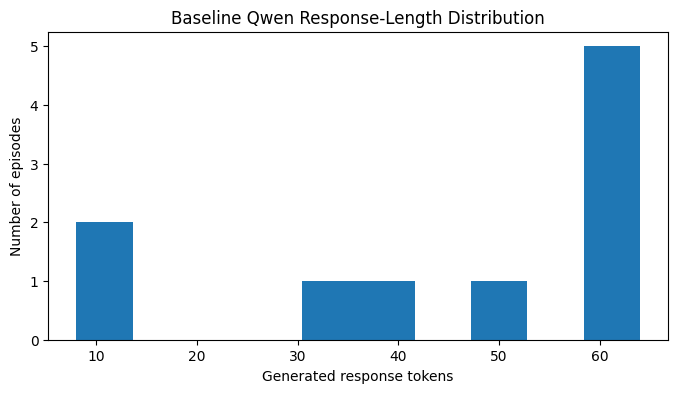

In [26]:
plt.figure(figsize=(8, 4))

plt.hist(
    metrics_df["response_tokens"],
    bins=min(10, len(metrics_df)),
)

plt.xlabel("Generated response tokens")
plt.ylabel("Number of episodes")
plt.title("Baseline Qwen Response-Length Distribution")

plt.show()

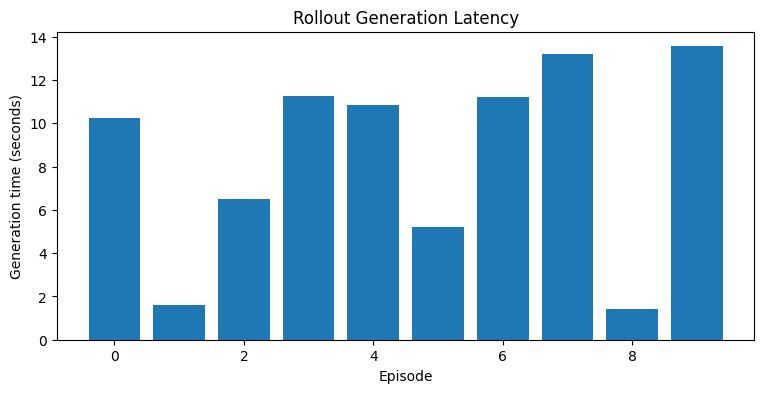

In [27]:
plt.figure(figsize=(9, 4))

plt.bar(
    metrics_df["episode"],
    metrics_df["generation_time_sec"],
)

plt.xlabel("Episode")
plt.ylabel("Generation time (seconds)")
plt.title("Rollout Generation Latency")

plt.show()

### Visualize Where Actions Occur

Let's create one compact visualization of the trajectory mask.

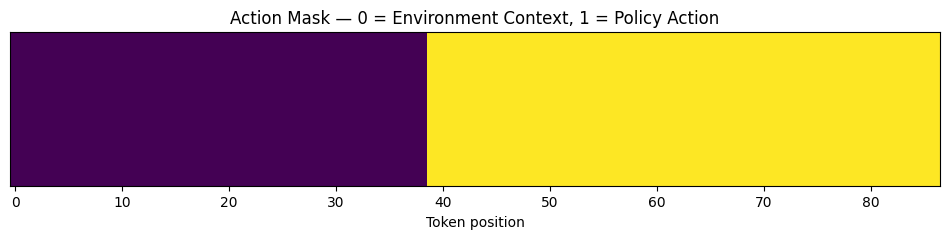

In [28]:
example = eval_trajectories[0]

mask_values = example.action_mask[0].int().numpy()

plt.figure(figsize=(12, 2))

plt.imshow(
    mask_values.reshape(1, -1),
    aspect="auto",
)

plt.yticks([])
plt.xlabel("Token position")
plt.title(
    "Action Mask — 0 = Environment Context, 1 = Policy Action"
)

plt.show()

In [29]:
def print_gpu_memory():
    if not torch.cuda.is_available():
        print("CUDA GPU not available.")
        return

    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_allocated = torch.cuda.max_memory_allocated() / 1024**3

    print(f"Allocated VRAM     : {allocated:.3f} GB")
    print(f"Reserved VRAM      : {reserved:.3f} GB")
    print(f"Peak allocated VRAM: {max_allocated:.3f} GB")


print_gpu_memory()

Allocated VRAM     : 2.884 GB
Reserved VRAM      : 3.086 GB
Peak allocated VRAM: 2.895 GB


In [30]:
for trajectory_i in eval_trajectories:
    validate_trajectory(trajectory_i)

assert len(eval_trajectories) == len(eval_prompts)

assert all(
    t.prompt_length > 0
    for t in eval_trajectories
)

assert all(
    t.response_length > 0
    for t in eval_trajectories
)

assert all(
    t.input_ids.shape == t.attention_mask.shape
    for t in eval_trajectories
)

assert all(
    t.input_ids.shape == t.action_mask.shape
    for t in eval_trajectories
)


All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.
All trajectory checks passed.


## Summary: Complete Rollout Pipeline

```text
Qwen 1.5B Policy
        │
        ▼
Chat Template
        │
        ▼
Environment Context
        │
        ▼
Autoregressive Sampling
        │
        ▼
Policy Actions
        │
        ├── prompt/response separation
        ├── action mask
        ├── attention mask
        ├── EOS detection
        ├── truncation detection
        │
        ▼
LLMTrajectory
        │
        ├── token-level inspection
        ├── validation assertions
        ├── sequence alignment inspection
        │
        ▼
Rollout Evaluation
        ├── response length
        ├── EOS rate
        ├── truncation rate
        ├── latency
        ├── throughput
        └── GPU memory
```

## Key Takeaway

And most importantly, you can now concretely interpret generation as:

$$s_t = (x, y_{<t})$$

$$a_t = y_t$$

$$\pi_\theta(a_t | s_t) = P_\theta(y_t | x, y_{<t})$$

Your Qwen model isn't merely "generating text" anymore.

It's a **stochastic policy** producing an **RL trajectory** one token at a time.

# RLHF System Architecture

Now we take the rollout collector from Lesson 3.1 and answer: **What extra models do we need around Qwen to actually train with PPO?**

### Clean Mental Model:

```text
                ┌─────────────────┐
Prompt ────────>│ Policy / Actor  │──────> Response
                │   Qwen 1.5B     │
                └────────┬────────┘
                         │
          ┌──────────────┼───────────────┐
          ▼              ▼               ▼
   Reference Model   Reward Model    Value Model
      "stay close"    "was it good?"  "how good from here?"
```

For PPO, these are **four logical roles**:

---

## 1. Policy Model

This is the Qwen model we already loaded (`model`). Renaming it now so the notebook becomes clearer:

```python
policy_model = model

print("Policy model:")
print(type(policy_model).__name__)
print("Training mode:", policy_model.training)
```

The policy does two things:
1. Generates trajectories
2. Gets updated by PPO

Mathematically:

$$\pi_\theta(a_t | s_t)$$

This is the only full language model whose behavior we're actively trying to change.

---

## 2. Reference Model

The reference policy answers: **What would the original model have done here?**

It is **frozen**.

* **Policy:** Qwen after RL updates
* **Reference:** Qwen before RL updates

Initially:

$$\pi_\theta = \pi_{\text{ref}}$$

As training progresses:

$$\pi_\theta \neq \pi_{\text{ref}}$$

We compare their probabilities to measure policy drift. Later:

$$\text{KL}(\pi_\theta \parallel \pi_{\text{ref}})$$

penalizes the policy for moving too far. In InstructGPT, PPO used a per-token KL penalty against the SFT policy specifically to reduce reward-model overoptimization.

---

## 3. Why Don't We Just Let PPO Change Qwen Freely?

Imagine our reward says: `+1` if answer contains `"45"`.

Qwen might eventually discover:

```text
45 45 45 45 45 45 45 45 45
```

* **Reward:** `+1`
* **Language quality:** Destroyed

RL doesn't care about being a good language model unless the objective captures it.

The reference model acts as an anchor:
$$\text{Maximize reward} \quad \mathbf{\text{BUT}} \quad \text{don't move absurdly far from the original useful model}$$

Later we'll experimentally remove this constraint and watch what happens.

---

## 4. Reward Model

The reward model answers: **Was the entire generated answer good?**

Conceptually:

```text
Prompt + Response
       │
       ▼
  Reward Model
       │
       ▼
     scalar
```

**Example:**

```text
Prompt: "What is 15 * 3?"

Response A: "45"                ──> reward = +1.8
Response B: "52"                ──> reward = -1.4
```

So:

$$R(x, y) \in \mathbb{R}$$

**Important distinction:**
* **Policy model:** Predicts tokens
* **Reward model:** Predicts a scalar score

---

## 5. Do We Always Need a Neural Reward Model?

**No.** And for our first PPO/GRPO builds, we shouldn't use one.

If the answer is objectively verifiable:
* Math
* Code unit tests
* Structured output
* Exact answers
* Environment success

We can use:

$$\text{reward} = \text{verifier}(\text{prompt}, \text{response})$$

instead of loading another 1.5B model. For your hardware, this matters a lot.

So our progression will be:
* **Stage 1:** Qwen policy + rule/verifier reward
* **Stage 2:** Qwen policy + learned reward model

That keeps the RL mechanics visible before adding another huge component.

---

## 6. Value Model / Critic

You know this from PPO already. It answers: **Given where the LLM currently is in the generation, how much future reward do I expect?**

For every generated position:

$$V_\phi(s_t)$$

**Example:**

```text
State: "What is 15 × 3? The answer is"      ──> V(s_t) =  0.82  (Likely to finish successfully)
State: "What is 15 × 3? The answer is 52"   ──> V(s_t) = -0.60  (State got worse)
```

---

## 7. The Critic Does NOT Generate Text

This distinction is worth making explicit:

```text
POLICY                             CRITIC
hidden state                    hidden state
     │                               │
     ▼                               ▼
  LM head                        value head
     │                               │
     ▼                               ▼
50k+ token logits                 1 scalar
```

So if Qwen hidden states have shape `[B, T, hidden_size]`, the value head does:

```text
[B, T, hidden_size]  ──Linear(hidden_size, 1)──>  [B, T, 1]  ──squeeze──>  [B, T]
```

That's it.


In [31]:
policy_model = model

print("Policy model:")
print(type(policy_model).__name__)
print("Training mode:", policy_model.training)

Policy model:
Qwen2ForCausalLM
Training mode: False


In [32]:
print("Hidden size :", policy_model.config.hidden_size)
print("Layers      :", policy_model.config.num_hidden_layers)
print("Vocab size  :", policy_model.config.vocab_size)

Hidden size : 1536
Layers      : 28
Vocab size  : 151936


### Build Our Value Head

We do not need another full Qwen yet. We can attach a tiny head to hidden states.


## Value Head — What It Actually Is

Your Qwen model normally does this:

```text
hidden state for each token
        ↓
LM head
        ↓
vocab logits
        ↓
next-token probabilities
```

For PPO, we also need a critic.

The critic asks:

"From this current state/prefix, how much future reward do I expect?"

So we attach another tiny linear layer to the same hidden states:

```text
hidden state
   ↓
Value Head: Linear(hidden_size → 1)
   ↓
single number V(s_t)
```

---

### Example

**Prompt:** `"What is 2+2?"`

**Generated so far:** `"The answer is"`

$$V(s_t) = 0.7$$

**Meaning:** the critic currently predicts this trajectory will probably end with decent reward.

Then after: `"The answer is 5"`

$$V(s_t) = -0.4$$

Maybe the critic predicts the final reward will be bad.

---

## Why PPO Needs It

PPO needs an advantage:

$$A_t = \text{how good was this action compared to what I expected?}$$

The value head gives the expectation:

$$V(s_t)$$

Then later GAE compares:

- actual reward / future return
- vs critic prediction

to estimate whether that token/action was better or worse than expected.

### Summary

**Policy head:**
"What token should I choose?"

**Value head:**
"How promising is the current state?"

---

## Why Add It to Qwen Instead of Another Model?

Because Qwen already computed a rich hidden vector for every token.

Suppose:

$$\text{hidden state} = 1536 \text{ numbers}$$

We just add:

$$1536 \rightarrow 1$$

That's only ~1537 parameters.

The head itself is tiny.

The expensive part is the Qwen backbone.

Normally in PPO-style RLHF, the value model is logically the critic.

It can be implemented as:

a completely separate model, or
the same backbone as the policy with an extra value head

In our setup, I attached the value head to the policy/Qwen backbone, not to a separate critic model.

So:

Qwen hidden states
   ├── LM head → policy logits
   └── Value head → V(s)

Logically:

LM head = actor/policy
value head = critic

Physically:

both share the same Qwen backbone to save VRAM.

In [33]:
import torch.nn as nn

class ValueHead(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        self.value_proj = nn.Linear(
            hidden_size,
            1,
            bias=True
        )

    def forward(self, hidden_states):
        """
        hidden_states:
            [batch, seq_len, hidden_size]

        returns:
            [batch, seq_len]
        """

        values = self.value_proj(hidden_states)

        values = values.squeeze(-1)

        return values

value_head = ValueHead(
    policy_model.config.hidden_size
).to(device=device, dtype=policy_model.dtype)

print(value_head)

value_head_params = sum(
    p.numel()
    for p in value_head.parameters()
)

print(
    f"Value head parameters: "
    f"{value_head_params:,}"
)

print(
    f"Value head size relative to Qwen: "
    f"{100 * value_head_params / num_params:.8f}%"
)


ValueHead(
  (value_proj): Linear(in_features=1536, out_features=1, bias=True)
)
Value head parameters: 1,537
Value head size relative to Qwen: 0.00009957%


In [34]:
example_trajectory = eval_trajectories[0]

example_input_ids = (
    example_trajectory
    .input_ids
    .to(device)
)

example_attention_mask = (
    example_trajectory
    .attention_mask
    .to(device)
)

print("Input shape:")
print(example_input_ids.shape)

with torch.inference_mode():

    outputs = policy_model(
        input_ids=example_input_ids,
        attention_mask=example_attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )

print(type(outputs))

Input shape:
torch.Size([1, 87])
<class 'transformers.modeling_outputs.CausalLMOutputWithPast'>


### Inspect What Qwen Produced


In [35]:
print("Logits shape:")
print(outputs.logits.shape)

print()

print(
    "Number of hidden-state tensors:",
    len(outputs.hidden_states)
)

print()

print(
    "Final hidden-state shape:",
    outputs.hidden_states[-1].shape
)

Logits shape:
torch.Size([1, 87, 151936])

Number of hidden-state tensors: 29

Final hidden-state shape: torch.Size([1, 87, 1536])


> **Key Distinction: Hidden States vs. Token Logits**
> 
> ```text
> hidden states  ──>  representation of each token
> LM head        ──>  token logits
> ```


### Feed Hidden States into Our Critic


In [36]:
final_hidden_states = outputs.hidden_states[-1]

with torch.inference_mode():
    token_values = value_head(
        final_hidden_states
    )

print(
    "Hidden states:",
    final_hidden_states.shape
)

print(
    "Values:",
    token_values.shape
)

Hidden states: torch.Size([1, 87, 1536])
Values: torch.Size([1, 87])


### Visualize the Critic Token by Token

The critic is random right now, so the values mean nothing.


In [37]:
value_rows = []

ids = example_trajectory.input_ids[0]

for position, token_id in enumerate(ids):

    token_text = tokenizer.decode(
        [int(token_id)],
        skip_special_tokens=False
    )

    value_rows.append({
        "position": position,
        "token": repr(token_text),
        "action": int(
            example_trajectory.action_mask[
                0,
                position
            ]
        ),
        "value": float(
            token_values[
                0,
                position
            ].cpu()
        ),
    })

value_df = pd.DataFrame(value_rows)

value_df

,position,token,action,value
0,0,'<|im_start|>',0,0.259766
1,1,'system',0,-0.045166
2,2,'\n',0,-0.137695
3,3,'You',0,4.187500
4,4,' are',0,5.125000
...,...,...,...,...
82,82,' ',1,3.359375
83,83,'8',1,5.343750
84,84,'4',1,0.515625
85,85,'.',1,-4.531250


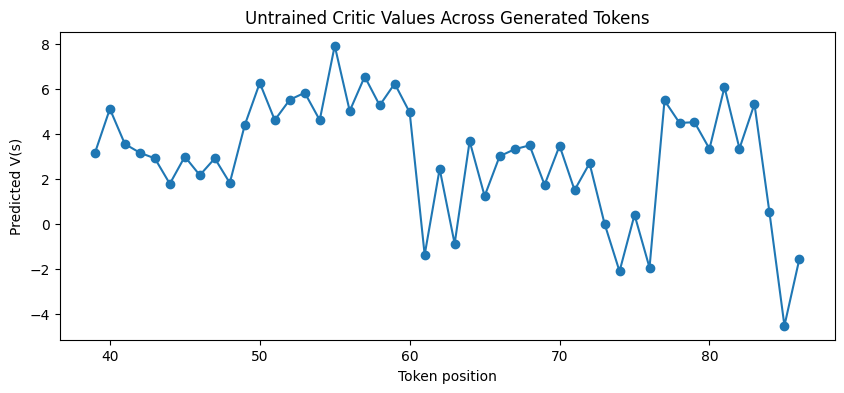

In [38]:
policy_region = value_df[
    value_df["action"] == 1
]

plt.figure(figsize=(10, 4))

plt.plot(
    policy_region["position"],
    policy_region["value"],
    marker="o"
)

plt.xlabel("Token position")
plt.ylabel("Predicted V(s)")
plt.title(
    "Untrained Critic Values Across Generated Tokens"
)

plt.show()

## Logical Topology vs. Physical Topology

This distinction is very important.

### Logical PPO Topology:
* Policy
* Reference
* Reward
* Value

Four roles.

---

### Physical System Setup:

That does **not** mean four separate Qwen 1.5B models have to sit in VRAM. Our physical system can look more like:

```text
Frozen Qwen Base
  │
  ├── LoRA policy
  │
  ├── reference = adapters disabled
  │
  └── value head

Reward: external verifier
```

So physically:
* $1 \times$ Qwen backbone
* $+$ tiny LoRA
* $+$ tiny value head
* $+$ verifier

That is much more realistic for hardware execution.


In [39]:
def model_parameter_memory_gb(model):

    total_bytes = 0

    for p in model.parameters():
        total_bytes += (
            p.numel()
            * p.element_size()
        )

    return total_bytes / 1024**3


policy_weight_memory = (
    model_parameter_memory_gb(
        policy_model
    )
)

value_head_memory = (
    model_parameter_memory_gb(
        value_head
    )
)

print(
    f"Policy weight memory: "
    f"{policy_weight_memory:.3f} GB"
)

print(
    f"Value head memory: "
    f"{value_head_memory:.6f} GB"
)

print()

print(
    "Naive policy + reference weights:"
)

print(
    f"{2 * policy_weight_memory:.3f} GB"
)

Policy weight memory: 2.875 GB
Value head memory: 0.000003 GB

Naive policy + reference weights:
5.751 GB


### Let's Create a Simple Verifier Reward

We aren't training yet. This is just to make the reward role concrete.


In [40]:
def exact_answer_reward(
    response: str,
    expected_answer: str,
):
    """
    Tiny deterministic reward.

    +1 if expected answer appears.
     0 otherwise.
    """

    if expected_answer.lower() in response.lower():
        return 1.0

    return 0.0

print(
    exact_answer_reward(
        "The answer is 45.",
        "45"
    )
)

print(
    exact_answer_reward(
        "The answer is 52.",
        "45"
    )
)

1.0
0.0


In [41]:
reward_example = collect_rollout(
    model=policy_model,
    tokenizer=tokenizer,
    prompt="What is 15 multiplied by 3?",
    max_new_tokens=32,
)

reward = exact_answer_reward(
    reward_example.response_text,
    expected_answer="45"
)

print("PROMPT:")
print(reward_example.prompt_text)

print("\nRESPONSE:")
print(reward_example.response_text)

print("\nREWARD:")
print(reward)

PROMPT:
What is 15 multiplied by 3?

RESPONSE:
The product of 15 and 3 is 45.

REWARD:
1.0


## Four Roles — One Concrete Example

Let's make the whole architecture concrete with an example.

**Prompt:** `"What is 15 × 3?"`

1. **Policy:**
   * Produces: `"The answer is 45."`
2. **Reference:**
   * Says indirectly through probabilities: *"This response is / isn't too different from how original Qwen would behave."*
3. **Reward:**
   * Says: `+1` because the answer is correct.
4. **Critic:**
   * Might eventually predict:
     ```text
     "The"              V = 0.40
     "The answer"       V = 0.60
     "The answer is"    V = 0.80
     "The answer is 45" V = 0.98
     ```

PPO combines these pieces to decide: **Which token choices should become more or less likely?**

That's the whole architecture.


one compact end-to-end pass

In [42]:
import copy

reference_model = copy.deepcopy(policy_model).eval()

for p in reference_model.parameters():
    p.requires_grad = False
traj = collect_rollout(
    model=policy_model,
    tokenizer=tokenizer,
    prompt="What is 15 multiplied by 3?",
    max_new_tokens=32,
)

input_ids = traj.input_ids.to(device)
attention_mask = traj.attention_mask.to(device)

with torch.no_grad():
    policy_out = policy_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )

    ref_out = reference_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        use_cache=False,
    )

    values = value_head(
        policy_out.hidden_states[-1]
    )

reward = exact_answer_reward(
    traj.response_text,
    "45"
)

print("Response:", traj.response_text)
print("Reward:", reward)
print("Values shape:", values.shape)

Response: To calculate \( 15 \times 3 \), you simply multiply the two numbers together:

\( 15 \times 3 = 45
Reward: 1.0
Values shape: torch.Size([1, 71])


# Token Logprobs & Importance Ratios

Now we hit one of the core PPO mechanics.

The important question is:

Qwen generated token 45. What probability did the policy assign to that exact action?

The model outputs logits for every vocab token.

Example:

vocab logits
[ ... 1.2, -0.4, 5.7, 0.8, ... ]
                 ↑
              token "45"

We only care about the log-probability of the token the policy actually took.

1. Logits → logprobs

From Qwen:

policy_out.logits.shape

is:

[B, T, vocab_size]

Convert logits into log-probabilities:

logP(a∣s)=logsoftmax(logits)

In [43]:
import torch.nn.functional as F

all_logprobs = F.log_softmax(
    policy_out.logits,
    dim=-1
)

print(all_logprobs.shape)

torch.Size([1, 71, 151936])


This is the part we simplified earlier:

input token at position t
        ↓
model sees it
        ↓
logits at position t
        ↓
predict token at t+1

In [44]:
logits = policy_out.logits[:, :-1]
targets = input_ids[:, 1:]

In [45]:
logprobs = F.log_softmax(
    logits,
    dim=-1
)

action_logprobs = logprobs.gather(
    dim=-1,
    index=targets.unsqueeze(-1)
).squeeze(-1)

print(action_logprobs.shape)

torch.Size([1, 70])


Now instead of:

[B, T-1, vocab]

we have:

[B, T-1]

One number per actual next token.

In [46]:
shifted_action_mask = traj.action_mask[:, 1:].to(device)

policy_action_logprobs = action_logprobs[
    shifted_action_mask
]

print(policy_action_logprobs)

tensor([-2.4219e+00, -1.2969e+00, -1.2578e+00, -3.4961e-01, -4.1962e-04,
        -3.4809e-05, -1.7071e-04, -1.0059e-01, -2.5034e-06, -8.2254e-06,
        -5.0783e-05, -7.6562e-01, -1.1377e-01, -4.2969e-01, -1.0498e-01,
        -4.5508e-01, -1.4062e-01, -1.6880e-04, -4.1748e-02, -1.5430e-01,
        -1.5703e+00, -9.8267e-03, -3.9864e-04, -1.4973e-04, -1.3638e-04,
        -5.4016e-03, -2.3842e-06, -6.5565e-06, -1.1749e-03, -1.1063e-03,
        -8.5354e-05, -2.3842e-07], device='cuda:0', dtype=torch.bfloat16)


In [47]:
response_targets = targets[shifted_action_mask]

for token_id, logp in zip(
    response_targets.tolist(),
    policy_action_logprobs.tolist()
):
    token = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    print(
        repr(token),
        "logprob =", round(logp, 4),
        "prob =", round(torch.exp(torch.tensor(logp)).item(), 4)
    )

'To' logprob = -2.4219 prob = 0.0888
' calculate' logprob = -1.2969 prob = 0.2734
' \\(' logprob = -1.2578 prob = 0.2843
' ' logprob = -0.3496 prob = 0.705
'1' logprob = -0.0004 prob = 0.9996
'5' logprob = -0.0 prob = 1.0
' \\' logprob = -0.0002 prob = 0.9998
'times' logprob = -0.1006 prob = 0.9043
' ' logprob = -0.0 prob = 1.0
'3' logprob = -0.0 prob = 1.0
' \\' logprob = -0.0001 prob = 0.9999
'),' logprob = -0.7656 prob = 0.465
' you' logprob = -0.1138 prob = 0.8925
' simply' logprob = -0.4297 prob = 0.6507
' multiply' logprob = -0.105 prob = 0.9003
' the' logprob = -0.4551 prob = 0.6344
' two' logprob = -0.1406 prob = 0.8688
' numbers' logprob = -0.0002 prob = 0.9998
' together' logprob = -0.0417 prob = 0.9591
':\n\n' logprob = -0.1543 prob = 0.857
'\\(' logprob = -1.5703 prob = 0.208
' ' logprob = -0.0098 prob = 0.9902
'1' logprob = -0.0004 prob = 0.9996
'5' logprob = -0.0001 prob = 0.9999
' \\' logprob = -0.0001 prob = 0.9999
'times' logprob = -0.0054 prob = 0.9946
' ' logprob = -

Old policy vs new policy

PPO does not ask:

Is this token probable?

It asks:

Did the probability of this action change too much after the update?

So we save:

$$ \log \pi_{\text{old}}(a_t|s_t) $$

during rollout.

Then after updating the model, calculate:

$$ \log \pi_{\theta}(a_t|s_t) $$

and compare them.

7. Importance ratio

Core PPO equation:

$$ r_t(\theta) = \frac{ \pi_\theta(a_t|s_t) }{ \pi_{\text{old}}(a_t|s_t) } $$

Numerically, we use logprobs:

$$ r_t = \exp( \log\pi_\theta - \log\pi_{\text{old}} ) $$

Why?

Because multiplying/dividing tiny probabilities is numerically ugly.

Approximate KL

A simple sampled approximation:

$$ \text{approx KL} \approx \log \pi_{old}(a_t|s_t) - \log \pi_{new}(a_t|s_t) $$
approx_kl = (
    old_logprobs
    - new_policy_action_logprobs
).mean()

print("Approx KL:", approx_kl.item())

Interpretation:

small KL  → policy barely moved
large KL  → policy changed a lot

PPO Clipped Objective

Now we finally use the ratio from 3.3.

One missing piece is the advantage \(A_t\):

\(A_t > 0\): that token/action was better than expected → make it more likely.
\(A_t < 0\): worse than expected → make it less likely.

We haven't implemented real GAE yet, so for this lesson we'll use fake advantages purely to understand PPO clipping. Real advantages come when we finish the critic/GAE part.

1. PPO without clipping

Naively:

$$ L = -r_t A_t $$

where:

$$ r_t = \frac{\pi_{\text{new}}(a_t|s_t)} {\pi_{\text{old}}(a_t|s_t)} $$

Suppose:

advantage = +1
ratio = 4

Then PPO would strongly reward that update.

Problem: the policy may move way too far in one step.

So PPO limits it.

2. Clipped objective

The important equation:

$$ L^{CLIP} = -\min \left( r_tA_t, \operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_t \right) $$

Usually:

$$ \epsilon = 0.2 $$

so the allowed ratio region is roughly:

$$ 0.8 \le r_t \le 1.2 $$
3. Use our ratio from 3.3

Let's create temporary advantages matching the number of generated tokens.

advantages = torch.randn_like(ratio)

print("Advantages:", advantages)
print("Ratios:    ", ratio)

Again, these advantages are fake only for understanding the loss.

The intuition

Forget the formula for a second.

PPO basically says:

GOOD action:
    increase probability
    but don't increase it too much

BAD action:
    decrease probability
    but don't decrease it too much

But:

if you're moving in the WRONG direction,
PPO still lets the loss punish you fully.

That's the important part.

7. Clip fraction

Now an evaluation metric we'll keep permanently:

clip_fraction = (
    (torch.abs(ratio - 1.0) > clip_eps)
    .float()
    .mean()
)

print("Clip fraction:", clip_fraction.item())

Meaning:

clip_fraction = 0.05
→ 5% of token updates crossed the clipping region

If this suddenly becomes huge:

0.7
0.8
0.9

your PPO updates are probably too aggressive.

Possible causes:

learning rate too high
too many PPO epochs
advantages too large
stale rollout policy

Our reusable actor-loss function

Now package only what we'll actually reuse:

In [48]:
def ppo_policy_loss(
    new_logprobs,
    old_logprobs,
    advantages,
    clip_eps=0.2,
):
    ratio = torch.exp(
        new_logprobs - old_logprobs
    )

    unclipped = ratio * advantages

    clipped = (
        torch.clamp(
            ratio,
            1 - clip_eps,
            1 + clip_eps
        )
        * advantages
    )

    loss = -torch.min(
        unclipped,
        clipped
    ).mean()

    clipfrac = (
        (torch.abs(ratio - 1) > clip_eps)
        .float()
        .mean()
    )

    return loss, ratio, clipfrac

Real Advantages with Value Head + Token-Level GAE

reward
+
critic value V(s)
↓
GAE
↓
advantage
↓
PPO loss

What the critic gives us

For each generated token/state:

$$ V(s_t) $$

Example:

"The"              → V = 0.3
"The answer"       → V = 0.5
"The answer is"    → V = 0.7
"The answer is 45" → V = 0.9

This is just the value head we already attached.

2. Reward for our trajectory

For now we use terminal reward only.

If:

response = "The answer is 45"
reward = 1

then token rewards are:

0  0  0  0  1

Only the final action gets the task reward.

Minimal code

In [49]:
# values for only generated/action tokens
action_values = values[:, 1:][shifted_action_mask]

# terminal reward
task_reward = torch.tensor(
    reward,
    dtype=torch.float32,
    device=device
)

rewards = torch.zeros_like(action_values)
rewards[-1] = task_reward

print("Values :", action_values)
print("Rewards:", rewards)

Values : tensor([ 3.4375,  5.3125,  3.4375,  2.6875,  3.7188,  1.3594,  3.1406,  1.6172,
         1.8750,  2.2188,  4.4688,  6.0625,  4.3125,  3.2344,  4.8125,  4.1562,
         2.6250,  1.9766,  4.1250, -1.7031,  3.5469,  1.8203,  4.6250,  0.9922,
         3.0781,  2.7812,  2.5938,  1.5625,  2.0469,  1.1250,  2.1875, -0.5938],
       device='cuda:0', dtype=torch.bfloat16)
Rewards: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       device='cuda:0', dtype=torch.bfloat16)


3. TD error

Core equation:

$$ \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t) $$

Meaning:

Was the next outcome better or worse than the critic expected?

Example:

critic expected 0.4
next state + reward implies 0.8

delta = +0.4

Good surprise.

4. GAE

Instead of using only one-step TD error, GAE accumulates future TD errors:

$$ A_t = \delta_t + \gamma\lambda A_{t+1} $$

Usually:

gamma ≈ 1.0
lambda ≈ 0.95

For LLM responses, gamma=1 is common because we're usually not trying to discount later tokens heavily.

In [50]:
def compute_gae(
    rewards,
    values,
    gamma=1.0,
    lam=0.95,
):
    advantages = torch.zeros_like(rewards)

    next_value = torch.tensor(0.0, device=rewards.device)
    next_advantage = torch.tensor(0.0, device=rewards.device)

    for t in reversed(range(len(rewards))):
        delta = (
            rewards[t]
            + gamma * next_value
            - values[t]
        )

        advantages[t] = (
            delta
            + gamma * lam * next_advantage
        )

        next_value = values[t]
        next_advantage = advantages[t]

    returns = advantages + values

    return advantages, returns

In [51]:
advantages, returns = compute_gae(
    rewards,
    action_values.detach(),
)

print("Rewards   :", rewards)
print("Values    :", action_values)
print("Advantages:", advantages)
print("Returns   :", returns)

Rewards   : tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       device='cuda:0', dtype=torch.bfloat16)
Values    : tensor([ 3.4375,  5.3125,  3.4375,  2.6875,  3.7188,  1.3594,  3.1406,  1.6172,
         1.8750,  2.2188,  4.4688,  6.0625,  4.3125,  3.2344,  4.8125,  4.1562,
         2.6250,  1.9766,  4.1250, -1.7031,  3.5469,  1.8203,  4.6250,  0.9922,
         3.0781,  2.7812,  2.5938,  1.5625,  2.0469,  1.1250,  2.1875, -0.5938],
       device='cuda:0', dtype=torch.bfloat16)
Advantages: tensor([-0.8125, -2.8281, -1.0078, -0.2734, -1.3750,  1.0391, -0.7812,  0.7812,
         0.5508,  0.2188, -2.1406, -3.9375, -2.2969, -1.2812, -3.0156, -2.4844,
        -1.0000, -0.3750, -2.6719,  3.3125, -2.0312, -0.3281, -3.3125,  0.3359,
        -1.8516, -1.6328, -1.5234, -0.5156, -1.0547, -0.1406, -1.2656,  1.5938],
       device='cuda:0', dtype=torch.bfloat16)
Returns   : tensor([2.6250, 2.4844, 2.4

What return means

Very important distinction:

Value:
what critic predicted

Return:
what target the critic should have predicted

Advantage:
return - prediction

Essentially:

$$ A_t \approx R_t - V(s_t) $$

and therefore:

$$ R_t^{target} = A_t + V(s_t) $$

That's exactly why we wrote:

returns = advantages + values

Train the critic

The policy learns:

which tokens should become more/less likely?

The critic learns:

what return should I expect from this state?

Simple value loss:

L
V
	​

=(V(s
t
	​

)−R
t
	​

)
2

In [52]:
for token_id, r, v, a, ret in zip(
    response_targets.tolist(),
    rewards.tolist(),
    action_values.tolist(),
    advantages.tolist(),
    returns.tolist(),
):
    token = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    print(
        f"{repr(token):15} "
        f"reward={r:+.2f} "
        f"value={v:+.2f} "
        f"adv={a:+.2f} "
        f"return={ret:+.2f}"
    )

'To'            reward=+0.00 value=+3.44 adv=-0.81 return=+2.62
' calculate'    reward=+0.00 value=+5.31 adv=-2.83 return=+2.48
' \\('          reward=+0.00 value=+3.44 adv=-1.01 return=+2.44
' '             reward=+0.00 value=+2.69 adv=-0.27 return=+2.41
'1'             reward=+0.00 value=+3.72 adv=-1.38 return=+2.34
'5'             reward=+0.00 value=+1.36 adv=+1.04 return=+2.41
' \\'           reward=+0.00 value=+3.14 adv=-0.78 return=+2.36
'times'         reward=+0.00 value=+1.62 adv=+0.78 return=+2.41
' '             reward=+0.00 value=+1.88 adv=+0.55 return=+2.42
'3'             reward=+0.00 value=+2.22 adv=+0.22 return=+2.44
' \\'           reward=+0.00 value=+4.47 adv=-2.14 return=+2.33
'),'            reward=+0.00 value=+6.06 adv=-3.94 return=+2.12
' you'          reward=+0.00 value=+4.31 adv=-2.30 return=+2.02
' simply'       reward=+0.00 value=+3.23 adv=-1.28 return=+1.95
' multiply'     reward=+0.00 value=+4.81 adv=-3.02 return=+1.80
' the'          reward=+0.00 value=+4.16

9. What should happen after critic training?

Initially:

value predictions = garbage

So advantages are noisy.

As critic improves:

V(s_t) ≈ expected return

Then advantage becomes more meaningful:

positive advantage
→ action was better than expected

negative advantage
→ action was worse than expected

That reduces variance in the policy gradient.

This is the main reason PPO uses a critic.

10. Important eval metric: explained variance

Later we will track:

$$ EV = 1 - \frac{ Var(R - V) }{ Var(R) } $$

Interpretation:

~1   → critic predicts returns well
~0   → critic barely helps
<0   → critic is worse than predicting the mean

In [53]:
def explained_variance(values, returns):
    var_returns = torch.var(returns)

    if var_returns < 1e-8:
        return torch.tensor(0.0)

    return 1 - torch.var(
        returns - values
    ) / var_returns

We now have the real PPO chain::
Verifier reward
      ↓
Token rewards
      ↓
Value head V(s)
      ↓
TD errors
      ↓
GAE
      ↓
Advantages
      ↓
PPO actor loss

and

Returns
      ↓
Value loss
      ↓
Critic training

KL Control & Reference Policy

Normal PPO says:

maximize reward.

LLM PPO says:

maximize reward but don't drift too far from the original language model.

That second part is the reference-policy KL penalty. InstructGPT explicitly adds a per-token KL penalty against the SFT/reference model during PPO.

1. What are we comparing?

For every generated token:

policy logprob     = log πθ(a_t | s_t)
reference logprob  = log πref(a_t | s_t)

Then:

$$ k_t = \log \pi_\theta(a_t|s_t) - \log \pi_{\text{ref}}(a_t|s_t) $$

This sampled log-ratio tells us:

how differently is the current policy treating this token compared with original Qwen?

Strictly, individual token values can be positive or negative; its expectation under the policy corresponds to KL.

2. Why penalize it?

Without the reference:

reward ↑

could happen while Qwen destroys its original language behavior.

So we modify reward:

$$ r_t^{KL}=-\beta k_t $$

Then the final token also gets the actual task reward:

$$ r_T=r_T^{KL}+R_{\text{task}} $$

So:

token 1 → KL penalty
token 2 → KL penalty
token 3 → KL penalty
...
last    → KL penalty + task reward

In [54]:
with torch.no_grad():
    policy_logits = policy_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        use_cache=False,
    ).logits[:, :-1]

    ref_logits = reference_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        use_cache=False,
    ).logits[:, :-1]

policy_lp = F.log_softmax(policy_logits, dim=-1).gather(
    -1, targets.unsqueeze(-1)
).squeeze(-1)[shifted_action_mask]

ref_lp = F.log_softmax(ref_logits, dim=-1).gather(
    -1, targets.unsqueeze(-1)
).squeeze(-1)[shifted_action_mask]

print("Policy logprobs   :", policy_lp.shape)
print("Reference logprobs:", ref_lp.shape)

Policy logprobs   : torch.Size([32])
Reference logprobs: torch.Size([32])


Compute token-level KL penalty

In [55]:
beta = 0.1

sampled_kl = policy_lp - ref_lp

kl_reward = -beta * sampled_kl

print("Mean sampled KL:", sampled_kl.mean().item())
print("Mean KL reward :", kl_reward.mean().item())

Mean sampled KL: 0.0
Mean KL reward : 0.0


In [56]:
task_reward = exact_answer_reward(
    traj.response_text,
    expected_answer="45"
)

rewards_with_kl = kl_reward.clone()

rewards_with_kl[-1] += task_reward

print("Task reward:", task_reward)
print("Token rewards:", rewards_with_kl)
print("Total trajectory reward:", rewards_with_kl.sum().item())

Task reward: 1.0
Token rewards: tensor([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
        -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., 1.],
       device='cuda:0', dtype=torch.bfloat16)
Total trajectory reward: 1.0


In [57]:
for token_id, p, r, k, rew in zip(
    response_targets.tolist(),
    policy_lp.tolist(),
    ref_lp.tolist(),
    sampled_kl.tolist(),
    rewards_with_kl.tolist(),
):
    token = tokenizer.decode(
        [token_id],
        skip_special_tokens=False
    )

    print(
        f"{repr(token):15} "
        f"policy={p:7.3f} "
        f"ref={r:7.3f} "
        f"KL={k:+7.3f} "
        f"reward={rew:+7.3f}"
    )

'To'            policy= -2.422 ref= -2.422 KL= +0.000 reward= -0.000
' calculate'    policy= -1.297 ref= -1.297 KL= +0.000 reward= -0.000
' \\('          policy= -1.258 ref= -1.258 KL= +0.000 reward= -0.000
' '             policy= -0.350 ref= -0.350 KL= +0.000 reward= -0.000
'1'             policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
'5'             policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
' \\'           policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
'times'         policy= -0.101 ref= -0.101 KL= +0.000 reward= -0.000
' '             policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
'3'             policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
' \\'           policy= -0.000 ref= -0.000 KL= +0.000 reward= -0.000
'),'            policy= -0.766 ref= -0.766 KL= +0.000 reward= -0.000
' you'          policy= -0.114 ref= -0.114 KL= +0.000 reward= -0.000
' simply'       policy= -0.430 ref= -0.430 KL= +0.000 reward= -0.000
' multiply'     policy= -0.105 ref

7. What does β do?
$$ r_t^{KL}=-\beta k_t $$

So beta controls how strongly we care about staying close to the reference.

Small β
β = 0.01

Means:

chase reward aggressively.

Possible result:

reward ↑↑
KL ↑↑
language quality may degrade
Large β
β = 1.0

Means:

stay very close to original Qwen.

Possible result:

KL ↓
but policy barely learns

So there's a tradeoff:

               too small β
                   ↓
Reference ──────────────── RL reward optimum
        safer         aggressive drift

In [58]:
for beta in [0.01, 0.1, 0.5, 1.0]:
    penalty = -beta * sampled_kl

    print(
        f"beta={beta:<4} "
        f"mean penalty={penalty.mean().item():+.6f}"
    )

beta=0.01 mean penalty=+0.000000
beta=0.1  mean penalty=+0.000000
beta=0.5  mean penalty=+0.000000
beta=1.0  mean penalty=+0.000000


9. Fixed vs adaptive β
Fixed KL

Simplest:

beta = 0.1

It stays constant for the entire training run.

Problem:

KL too low → constraint unnecessarily strong
KL too high → constraint too weak

So some RLHF systems use an adaptive coefficient.

Adaptive idea

Choose a target:

target_KL = 0.05

Then:

actual KL > target
→ increase beta
→ stronger penalty

actual KL < target
→ decrease beta
→ weaker penalty

Minimal version:

In [59]:
def update_beta(beta, current_kl, target_kl, rate=0.1):
    if current_kl > target_kl:
        beta *= (1 + rate)
    else:
        beta /= (1 + rate)

    return beta

In [60]:
beta = 0.1
target_kl = 0.05

for current_kl in [0.02, 0.03, 0.08, 0.12, 0.04]:
    beta = update_beta(
        beta,
        current_kl,
        target_kl
    )

    print(
        f"KL={current_kl:.3f} → beta={beta:.4f}"
    )

KL=0.020 → beta=0.0909
KL=0.030 → beta=0.0826
KL=0.080 → beta=0.0909
KL=0.120 → beta=0.1000
KL=0.040 → beta=0.0909


10. The key distinction

We now have two different probability comparisons in PPO.

PPO old policy
$$ \pi_{\text{old}} $$

Used for:

$$ \frac{\pi_{\text{new}}}{\pi_{\text{old}}} $$

Purpose:

prevent a single PPO update from changing too aggressively.

Reference policy
$$ \pi_{\text{ref}} $$

Used for:

$$ \log \pi_\theta-\log \pi_{\text{ref}} $$

Purpose:

prevent the entire RL training process from drifting too far from original Qwen.

These are not the same model conceptually.

old policy
→ changes every rollout/update cycle

reference policy
→ stays frozen for the whole RL run

This distinction is important.

11. Our PPO reward now looks like

Before:

$$ r_t = \begin{cases} 0 & t<T\\ R_{\text{task}} & t=T \end{cases} $$

Now:

$$ r_t=-\beta \left( \log\pi_\theta(a_t|s_t) - \log\pi_{\text{ref}}(a_t|s_t) \right) $$

and at the final token:

$$ r_T \mathrel{+}=R_{\text{task}} $$

Then those rewards go into:

KL-adjusted rewards
       ↓
GAE
       ↓
advantages
       ↓
PPO clipped objective

That's the complete connection.

# PPO Stability & Diagnostics

When PPO is training, how do I know if it is healthy or silently going bad?

1. Advantage normalization

Suppose advantages look like:

[0.2, 0.4, 12.0, -7.0, 0.1]

Huge values can dominate the update.

So we commonly normalize:

$$ \hat A = \frac{A-\mu_A}{\sigma_A+\epsilon} $$

Meaning:

mean → 0
std  → 1

In [61]:
def normalize_advantages(advantages):
    return (
        advantages - advantages.mean()
    ) / (advantages.std() + 1e-8)

2. Value clipping

Remember:

Policy → PPO clipping

Critic → predicts V(s)

The critic can also change too aggressively.

Suppose:

old value = 0.3
new value = 4.7

from one update.

Bad.

So PPO can constrain value changes too:

In [62]:
value_clipped = old_values + torch.clamp(
    new_values - old_values,
    -0.2,
    0.2
)

NameError: name 'old_values' is not defined

3. Gradient norm

After:

loss.backward()

we want to know:

How large are the gradients trying to update Qwen?

In [ ]:
grad_norm = torch.nn.utils.clip_grad_norm_(
    policy_model.parameters(),
    max_norm=1.0
)

print("Gradient norm:", grad_norm.item())

Interpretation:

small/stable   → usually fine

constantly huge
→ optimizer is trying to make violent changes

NaN
→ something broke badly

Gradient clipping also prevents one bad batch from producing a massive update.

4. Entropy

This one is important for RL.

Entropy tells us roughly:

How uncertain/diverse is the policy?

High entropy:

many tokens have reasonable probability

Low entropy:

model becomes extremely confident/deterministic

If during RL:

reward ↑
entropy ↓↓↓↓↓

the model might be collapsing onto one repetitive strategy.

5. The main PPO dashboard

When we actually train Qwen, these are the metrics I want us recording every iteration:

Reward
KL
Policy loss
Value loss

Mean advantage
Advantage std

Mean ratio
Clip fraction

Entropy

Gradient norm

Response length
EOS rate
Truncation rate

Tokens/sec
VRAM

But they don't all tell the same story.

Reward
Is the policy optimizing our objective?
KL
How far are we drifting from original Qwen?
Clip fraction
How many PPO updates are trying to move too far?
Entropy
Is the policy collapsing?
Value loss
Is the critic learning?
Gradient norm
Are updates becoming unstable?
6. A useful diagnostic pattern

Suppose training shows:

Reward       ↑
KL           ↑↑↑
Entropy      ↓↓↓
Clip frac    ↑↑
Grad norm    ↑↑

That's not:

awesome, reward is increasing.

It's more like:

PPO is probably aggressively exploiting the reward and destabilizing Qwen.

Another run:

Reward       flat
KL           almost 0
Clip frac    0
Entropy      unchanged

Could mean:

policy is barely updating.

Possibly:

learning rate too small
KL penalty too strong
advantages too weak